<style>
    pre {
        white-space: pre-wrap;
        word-wrap: break-word;
    }
</style>

<div style="display:flex; justify-content:space-around; align-items:center; background-color:#cccccc; padding:5px; border:2px solid #333333;">
    <a href="https://www.um.es/web/estudios/grados/ciencia-ingenieria-datos/" target="_blank">
    <img src="images/umu_logo.png" alt="UMU" style="height:200px; width:auto;">
    <a href="https://estudios.upct.es/grado/5251/inicio" target="_blank">
    <img src="images/upct_logo.png" alt="UPCT" style="height:145px; width:auto;">
</div>

# Asignatura: **Deep Learning**

## Titulación: **Grado en Ciencia e Ingeniería de Datos**

## Práctica 2: Redes Convolucionales
### **Sesión 1/3: Introducción a las Redes Convolucionales**

**Autores**: Antonio Martínez Sánchez, Juan Morales Sánchez, José Luís Sancho Gómez y Juan Antonio Botía Blaya

<div style="page-break-before: always;"></div>

### Contenidos
- [Requisitos](#requisitos)
- [El dataset](#dataset)
- [MLP baseline](#mlp)
- [La red convolucional](#cnn)
- [Predicción](#prediccion)
- [Ejercicios](#ejercicios)

### Requisitos
<a class='anchor' id='requisitos'></a>

Se trabajará con notebooks de [Jupyter](https://jupyter.org/install) con código Python empleando como intérprete la última versión de [Miniconda](https://docs.anaconda.com/miniconda/). Se requiere la preinstalación (se recomienda utilizar [pip](https://pypi.org/project/pip/)) de los siguientes paquetes de Python:

- [Numpy](https://pypi.org/project/numpy/) (computación numérica)
- [Scipy](https://pypi.org/project/scipy/) (computación científica)
- [Tensorflow](https://www.tensorflow.org/install/pip?hl=es-419#linux) que incluye a Keras (deep Learning)
- [Scikit-learn](https://pypi.org/project/scikit-learn/) (machine Learning)
- [Scikit-image](https://pypi.org/project/scikit-image/) (Image processing)
- [Matplotlib](https://pypi.org/project/matplotlib/) and [Seaborn](https://pypi.org/project/seaborn/) (visualización de datos)

### El dataset
<a class='anchor' id='dataset'></a>

Los datos a procesar en esta práctica son un conjunto de imágenes sintéticas de criomicroscopía electrónica (acrónimo en inglés, cryo-EM). Cada imagen contiene una proyección 2D de una instancia de un determinado complejo molecular a una orientación aleatoria, específicamente los hay de cinco clases que según su código en la base de datos Protein Data Bank ([PDB](https://www.rcsb.org/)):
1. [3j9i](https://www.rcsb.org/structure/3J9I)
2. [4cr2](https://www.rcsb.org/structure/4CR2)
3. [4v4r](https://www.rcsb.org/structure/4V4R)
4. [4v94](https://www.rcsb.org/structure/4V94)
5. [6utj](https://www.rcsb.org/structure/6UTJ)

Las imágenes tienen un tamaño de 50x50 píxeles y están guardadas en ficheros en formato PNG. El nombre de estos ficheros determina el nombre de la clase, el identificador de clase y el número de partícula de esta clase. El conjunto de datos se encuentra en el directorio *images/SNR_high*.

Para poder entrenar el modelo es necesario cargar las imágenes de disco y convertirlas en tensores (arrays n-dimensionales). Las etiquetas de la clase a las que pertenece cada imagen se pueden extraer del nombre de las imágenes. Es probable que al leer las imágenes de disco se vayan leyendo secuencialmente para cada clase, este orden en las imágenes podría distorsionar el entrenamiento, por esto, una vez leídas, se puede aleatorizar su orden gracias a la funcionalidad que ofrece el paquete para machine learning de Python scikit-learn. Finalmente, se tendrá que particionar los datos de entrada en dos conjuntos: entrenamiento y test.

PARA CARGARLAS EN TENSORES, MIRAR SESIONES ANTERIORES

### MLP baseline
<a class='anchor' id='mlp'></a>

Un perceptrón multicapa (acrónimo en inglés, MLP) es una red neuronal de carácter genérico que puede adaptarse para resolver el problema de la clasificación de imágenes.

A modo de punto de partida, *baseline*, implementaremos un MLP que resuelva el problema de clasificación de las imágenes presentadas en el [Dataset](#dataset) según el complejo molecular al que pertenecen. Este MLP tendrá una arquitectura *encoder* con 4 capas ocultas, con un número de neuronas de 512, 256, 128 y 64 respectivamente, con funciones de activación ReLU. La capa de entrada recibirá la información de cada uno de los píxeles de entrada de forma desestructura, o aplanada, esto es, la red tendrá 50x50=2500 variables de entrada. En cuanto a la salida, tendrá una variable de salida por clases que determina la probabilidad de que una entrada pertenezca a una determinada clase. 

### La red convolucional
<a class='anchor' id='cnn'></a>

Las redes convolucionales implementan filtros que se pueden aplicar a señales que varían en función del tiempo y/o espacio como las imágenes y las señales de vídeo. Estos filtros se basan en la operación de convolución y procesan las señales teniendo en cuenta su redundancia espacial y/o temporal de las señales por lo que suelen ser muy eficientes. Al contrario que el MLP, no son generalistas y por si solas no son capaces de resolver algunas tareas. Sin embargo, las primeras redes convolucionales (CNN) se construyeron para resolver el problemas de clasificación de imágenes [LeNet](https://doi.org/10.1109%2F5.726791), es más a partir de [AlexNet](https://doi.org/10.1145%2F3065386) las CNN han demostrado ser la aproximación más efectiva para esta y otras tareas de análisis de imágenes.

En el problema de clasificación, se utilizan diversas capas CNN en forma de encoder para representar la información de la imagen en un espacio menor al determinado por todos los píxeles de imagen. Ten en cuenta que una capas convolucionales suelen tener pocos parámetros. Después, el MLP clasifica la imagen en función a partir del espacio de representación reducido, lo que a su vez permitirá disminuir considerablemente el tamaño del MLP. 

Los paquetes de Python *tensorflow* y *keras* permiten pueden construir redes neuronales de una manera muy simple. En esta práctica se construirá una red neuronal compuesta por un encoder CNN que extraerá una representación comprimida de la imagen y a su salida se añadirá un MLP para predecir las clases de cada imagen.

### Predicción
<a class='anchor' id='prediccion'></a>

Una vez el modelo se ha entrenado, éste se puede utilizar en modo *forward* para procesar cualquier imagen de entrada. Este proceso es particularmente eficiente si se procesan conjuntos de imágenes.

Una vez entrenado un modelo, se suele realizar una evaluación más detallada empleando otros conjuntos de datos. Aquí vamos a reutilizar los del entrenamiento, preferiblemente las imágenes usadas en el conjunto de validación, para evaluar las prestaciones del modelo. 

En el problema de clasificación multiclase, como es el caso, las matrices de confusión permiten un análisis más detallado de las prestaciones del modelo que las métricas globales como la precisión. Específicamente, permite determinar para cada clase el número de errores y que otras clases se han asignado sus instancias.

### Ejercicios
<a class='anchor' id='ejercicios'></a>

**E1:** Carga las imágenes de entrada y sus identificadores de clase correspondientes. Almacénalos en dos tensores con las dimensiones adecuadas para servir de entrada y salida (entrenamiento) respectivamente de la red neuronal construida.

### FUNCIÓN DE CARGA DE IMÁGENES DESDE DIRECTORIO

In [1]:
from tensorflow.keras.utils import get_file
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import os
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.utils import shuffle

# Dataset no incluido en este repositorio; coloca las imagenes en data/SNR_high.
base_dir = 'data/SNR_high'

# Preparar listas para imágenes y etiquetas
images = []
labels = []
class_names = ['0','1','2','3','4']

# Iterar sobre las imágenes PNG
for file_name in sorted(os.listdir(base_dir)):
    if file_name.endswith(".png"):
        img_path = os.path.join(base_dir, file_name)
        img = load_img(img_path, target_size=(50, 50), color_mode='grayscale')
        img_array = img_to_array(img) / 255
        name, label, name = file_name.split('_')
        images.append(img_array)
        labels.append(int(label) - 1)

# Convertir a arrays de NumPy
images = np.array(images, dtype=np.float32)
labels = np.array(labels)


**E2:** Aleatoriza la posición de las imágenes y consecuentemente los identificadores.

### ALEATORIZACIÓN DE DATOS

In [2]:
images, labels = shuffle(images, labels, random_state = 42)

**E3:** Particiona los tensores de entrada en dos, asigna el 80% de las imágenes para el entrenamiento y el 20% para la validación.

In [3]:
num_samples = len(images)
split_idx = int(0.8 * num_samples)

x_train = images[:split_idx]
x_test = images[split_idx:]

y_train = labels[:split_idx]
y_test = labels[split_idx:]

**E4:** Construye un MLP que realice la clasificación de las imágenes según se especifica en el apartado [MLP baseline](mlp). Utiliza el algoritmo de optimización y la función de pérdidas que creas más oportuna. USAR ADAM DE OPTIMIZADOR CON LEARNING RATE POR DEFECTO

In [4]:
model = Sequential([
	layers.Flatten(input_shape = (50,50,1)),
    Dense(512, activation='relu'),
	Dense(256, activation='relu'),
	Dense(128, activation='relu'),
	Dense(64, activation='relu'),
    Dense(5, activation='softmax') 
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy']) # Sparse porque tenemos 5 clases

c:\Users\cgeal\Desktop\Notebooks\venv3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


**E5:** ¿Cuántos parámetros a entrenar tendría esta red? SUMMARY DEL MODELO

In [5]:
print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 2500)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,280,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,453,317 (5.54 MB)

 Trainable params: 1,453,317 (5.54 MB)

 Non-trainable params: 0 (0.00 B)

None


El total de parámetros a entrenar de esta red sería 1.453.317

**E6:** Entrena el modelo y encuentra la combinación de tamaño de batch y épocas que genere mejores resultados. 

In [10]:
history = model.fit(x_train, y_train,
    validation_split=0.2,
    batch_size=32,
    epochs=20)

# Evaluar el modelo en el conjunto de validación
loss, accuracy = model.evaluate(x_test, y_test)
print(f"Precisión en datos de validación: {accuracy:.2f}")
print(f"Pérdida: {loss}")


Epoch 1/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7375 - loss: 0.6350 - val_accuracy: 0.7125 - val_loss: 0.7075
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7406 - loss: 0.6166 - val_accuracy: 0.7250 - val_loss: 0.6963
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7437 - loss: 0.6046 - val_accuracy: 0.6625 - val_loss: 0.7388
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7188 - loss: 0.6324 - val_accuracy: 0.7000 - val_loss: 0.7085
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7531 - loss: 0.6103 - val_accuracy: 0.7375 - val_loss: 0.6869
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7437 - loss: 0.6042 - val_accuracy: 0.7250 - val_loss: 0.6930
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7656 - loss: 0.5826 - val_accuracy: 0.7250 - val_loss: 0.6900
Epoch 8/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7812 - loss: 0.5795 - val_accuracy: 0.7000 - v

**E7:** Muestra la evolución de la función de pérdidas para los conjuntos de datos de entrenamiento y validación a lo largo del proceso de entrenamiento.

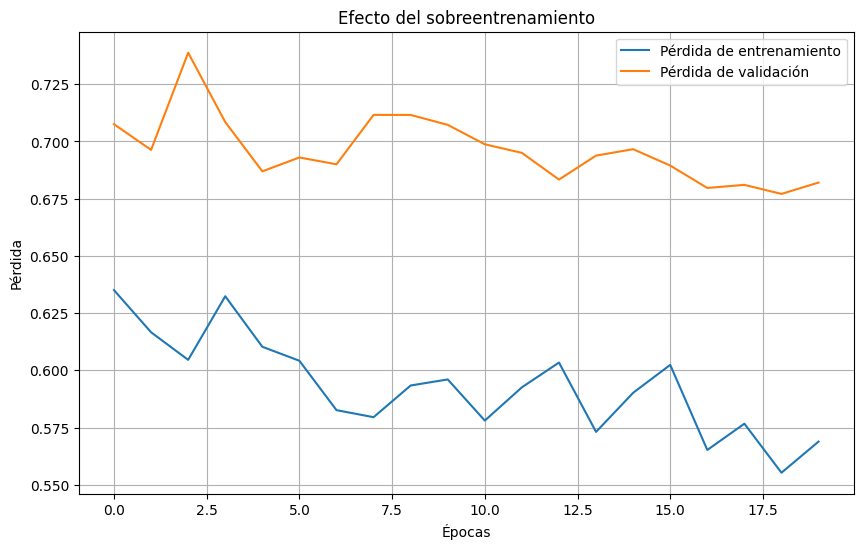

In [11]:
# Graficar las curvas de pérdida
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Pérdida de entrenamiento')
plt.plot(history.history['val_loss'], label='Pérdida de validación')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.title('Efecto del sobreentrenamiento')
plt.legend()
plt.grid(True)
plt.show()

**E8:** ¿Qué precisión tiene el modelo?

La precisión de un 64%

**E9:** Construye una red neuronal para clasificar las imágenes del dataset que contenga capas convolucionales y un MLP. Utiliza el algoritmo de optimización y la función de pérdidas que creas más oportuna.


In [24]:
# CONVOLUCIONAL DE 32 DE 3X3
# CONVOLUCIONAL DE 64 DE 3X3
# CONVOLUCIONAL DE 128 DE 3X3

# Y YA EL MLP

modelo_CNN = Sequential([
	layers.Input(shape=(50,50,1)),
	
	# Primer bloque convolucional
	layers.Conv2D(32, (3,3), activation='relu'), # 3x3 es el tamaño del filtro que se aplica
	layers.MaxPooling2D((2,2)),

	# Segundo bloque convolucional
	layers.Conv2D(64, (3,3), activation='relu'),
	layers.MaxPooling2D((2,2)),

	# Tercer bloque convolucional
	layers.Conv2D(128, (3,3), activation='relu'),
	layers.MaxPooling2D((2,2)),

	# Capas aplanadas y capas totalmente conectadas
	layers.Flatten(),
	layers.Dense(128, activation='relu'),
	layers.Dense(5, activation='softmax')
])

modelo_CNN.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy']) # Sparse porque tenemos 5 clases


**E10:** ¿Cuántos parámetros a entrenar tendría esta red? Compáralos con los que se obtuvieron con el MLP.

In [25]:
modelo_CNN.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 22, 22, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 11, 11, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 9, 9, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 355,589 (1.36 MB)

 Trainable params: 355,589 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

El número de parámetros es de 355589.

**E11:** Entrena el modelo y determina la precisión de la clasificación. Discute los resultados en comparación con los que se obtuvieron con el MLP

In [26]:
history_CNN = modelo_CNN.fit(x_train, y_train,
    validation_split=0.2,
    batch_size=4,
    epochs=30)

# Evaluar el modelo en el conjunto de validación
loss, accuracy = modelo_CNN.evaluate(x_test, y_test)
print(f"Precisión en datos de validación: {accuracy:.2f}")
print(f"Pérdida: {loss}")

Epoch 1/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.2281 - loss: 1.6157 - val_accuracy: 0.1125 - val_loss: 1.6204
Epoch 2/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3031 - loss: 1.5729 - val_accuracy: 0.3500 - val_loss: 1.4255
Epoch 3/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4688 - loss: 1.1874 - val_accuracy: 0.6000 - val_loss: 1.0006
Epoch 4/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5750 - loss: 0.9697 - val_accuracy: 0.6500 - val_loss: 0.8570
Epoch 5/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6594 - loss: 0.8757 - val_accuracy: 0.6375 - val_loss: 0.8595
Epoch 6/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7563 - loss: 0.6770 - val_accuracy: 0.7375 - val_loss: 0.6973
Epoch 7/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7969 - loss: 0.5577 - val_accuracy: 0.7750 - val_loss: 0.6506
Epoch 8/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8313 - loss: 0.4891 - val_accuracy: 0.7875 - val_loss:

Con 4 veces menos de parámetros, se ha obtenido un accuracy bastante mayor que en el MLP, pero sigue sin ser bueno del todo.  En este caso se obtiene un 2% más de accuracy con un batch pequeño con un batch grande. Esto se puede deber a que un batch pequeño en el caso de un dataset pequeño como este con cerca de 1000 datos, reduce el sobreajuste y mejora la generalización ya que el gradiente se calcula con muy pocos ejemplos. Introduce ruido en el gradiente que puede mejorar la generalización. Con un batch pequeño se hacen más actualizaciones y hay más oportunidades para ajustar los pesos. Con batch grande se puede producir sobre ajuste como es el caso. Los pequeños tienden a convenger hacia mínimos más planos del espacio de pérdida.

**E12:** Muestra la matriz de confusión resultado de procesar el conjunto de datos de test.

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


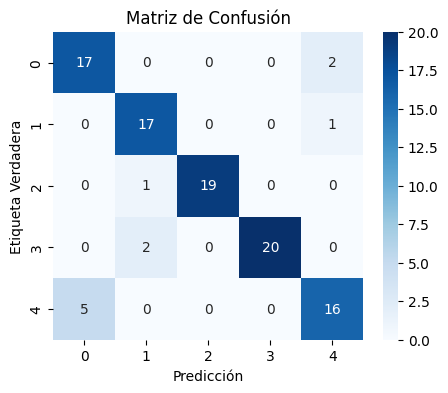

In [27]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_pred = np.argmax(modelo_CNN.predict(x_test), axis=-1)
q =modelo_CNN.predict(x_test)

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusión')
plt.xlabel('Predicción')
plt.ylabel('Etiqueta Verdadera')
plt.show()

**E13:** ¿Qué dos clases presentan mayor confusión mutua? ¿Por qué? Visualiza unas cuantas imágenes con clasificaciones correctas e incorrectas.

Las clases que mayor confusión mutua presentan son la 0 y la 4 ya que ha ocurrido en 5 ocasiones que proteinas pertenecientes a la clase 0, se han predicho como clase 4.

In [28]:
# Extracción de imagenes con clasificaciones correctas e incorrectas

correct_mask = y_pred == y_test
incorrect_mask = y_pred != y_test

correct_indices = np.where(correct_mask)[0]
incorrect_indices = np.where(incorrect_mask)[0]

class_id = 4

correct_class_2 = np.where(
    (y_test == class_id) & (y_pred == class_id)
)[0]

incorrect_class_2 = np.where(
    (y_test == class_id) & (y_pred != class_id)
)[0]

print(correct_class_2)

[ 2  4  5 21 22 29 45 48 58 68 71 75 86 89 91 98]


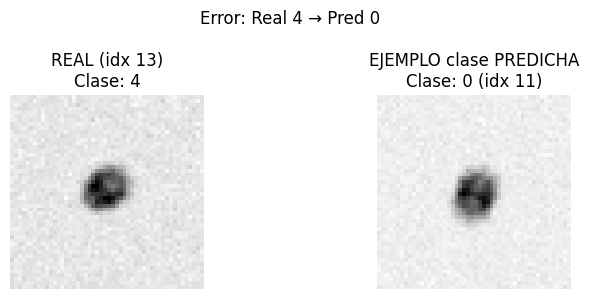

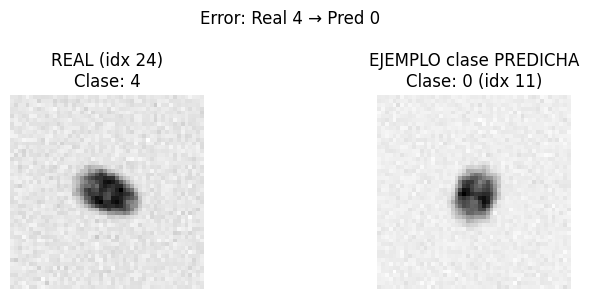

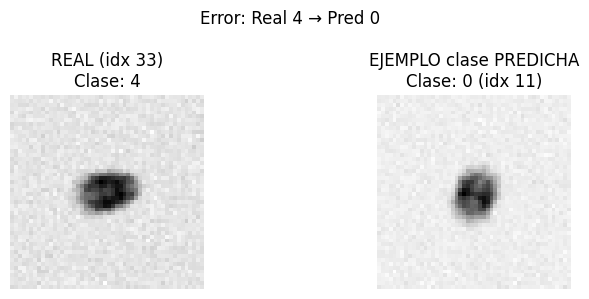

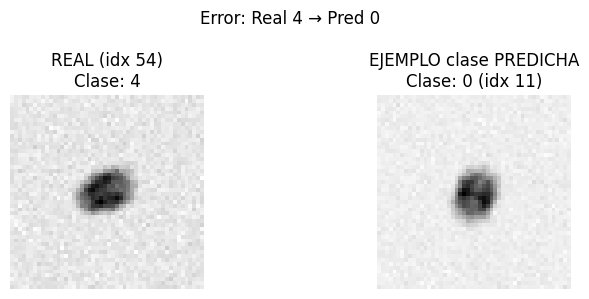

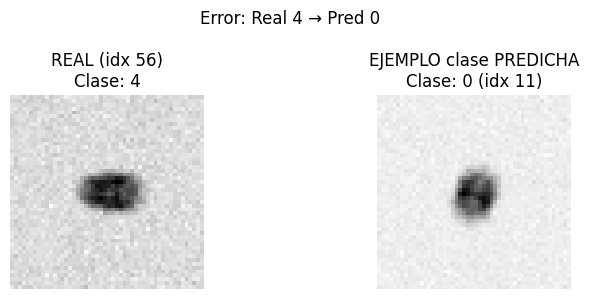

In [29]:
import numpy as np
import matplotlib.pyplot as plt

def denorm_for_show(img):
    img = img.astype(np.float32)
    if img.min() < 0:              # [-1, 1] -> [0, 1]
        img = (img + 1.0) / 2.0
    return np.clip(img, 0.0, 1.0)

def to_gray(img):
    if img.ndim == 3 and img.shape[-1] == 3:
        return 0.299*img[...,0] + 0.587*img[...,1] + 0.114*img[...,2]
    if img.ndim == 3 and img.shape[-1] == 1:
        return img[...,0]
    return img

def show_incorrect_real_vs_predclass(X, y_test, y_pred, incorrect_indices, class_names=None, n=10, random=False):
    incorrect_indices = np.array(incorrect_indices, dtype=int)
    if len(incorrect_indices) == 0:
        print("No hay índices incorrectos para mostrar.")
        return

    n = min(n, len(incorrect_indices))
    chosen = np.random.choice(incorrect_indices, size=n, replace=False) if random else incorrect_indices[:n]

    # Precalcular para cada clase: índices en el dataset con esa clase real
    class_to_indices = {}
    for c in np.unique(y_test):
        class_to_indices[int(c)] = np.where(y_test == c)[0]

    for idx in chosen:
        true_c = int(y_test[idx])
        pred_c = int(y_pred[idx])

        # Imagen REAL (la del error)
        img_true = to_gray(denorm_for_show(X[idx]))

        # Imagen "correspondiente a la predicha": una imagen cuya clase real sea pred_c
        if pred_c in class_to_indices and len(class_to_indices[pred_c]) > 0:
            # Elige una imagen de la clase predicha (por defecto la primera)
            idx_predimg = class_to_indices[pred_c][0]

            # Si prefieres aleatoria dentro de la clase predicha:
            # idx_predimg = np.random.choice(class_to_indices[pred_c])

            img_predclass = to_gray(denorm_for_show(X[idx_predimg]))
        else:
            idx_predimg = None
            img_predclass = None

        true_txt = class_names[true_c] if class_names is not None else str(true_c)
        pred_txt = class_names[pred_c] if class_names is not None else str(pred_c)

        fig, axes = plt.subplots(1, 2, figsize=(8, 3))

        axes[0].imshow(img_true, cmap="gray")
        axes[0].axis("off")
        axes[0].set_title(f"REAL (idx {idx})\nClase: {true_txt}")

        if img_predclass is not None:
            axes[1].imshow(img_predclass, cmap="gray")
            axes[1].axis("off")
            axes[1].set_title(f"EJEMPLO clase PREDICHA\nClase: {pred_txt} (idx {idx_predimg})")
        else:
            axes[1].axis("off")
            axes[1].set_title(f"No hay ejemplos\npara clase {pred_txt}")

        fig.suptitle(f"Error: Real {true_txt} → Pred {pred_txt}", fontsize=12)
        plt.tight_layout()
        plt.show()


# ---- USO ----
# class_names = ['3j9i', '4cr2', '4v4r', '4v94', '6utj']
class_names = None

show_incorrect_real_vs_predclass(x_test, y_test, y_pred, incorrect_class_2, class_names=class_names, n=5, random=False)
